In [2]:
import numpy as np

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("ecommerce_customers_unit1 (1).csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         605 non-null    int64  
 1   age                 577 non-null    float64
 2   gender              571 non-null    str    
 3   country             573 non-null    str    
 4   signup_date         605 non-null    str    
 5   last_purchase_date  605 non-null    str    
 6   num_orders          605 non-null    int64  
 7   total_spent         571 non-null    float64
 8   avg_order_value     605 non-null    float64
 9   recency_days        605 non-null    int64  
 10  is_premium_member   605 non-null    int64  
 11  device_type         575 non-null    str    
 12  preferred_category  583 non-null    str    
 13  churned             605 non-null    int64  
dtypes: float64(3), int64(5), str(6)
memory usage: 91.4 KB


In [6]:
df.describe

<bound method NDFrame.describe of      customer_id   age  gender  country signup_date last_purchase_date  \
0          10001  56.0    Male    India  2022-01-27         2024-04-27   
1          10002  69.0   Other       UK  2025-01-12         2025-08-01   
2          10003  46.0  Female      USA  2021-04-25         2021-06-01   
3          10004  32.0    Male    India  2021-02-23         2023-09-22   
4          10005  60.0  Female    India  2021-06-07         2021-12-11   
..           ...   ...     ...      ...         ...                ...   
600        10358  25.0  Female    India  2023-09-04         2025-06-18   
601        10117  50.0    Male      USA  2024-05-11         2024-11-08   
602        10599  46.0    Male    India  2020-12-01         2024-06-25   
603        10442  32.0  Female       UK  2023-12-20         2024-09-20   
604        10555  44.0  Female  Germany  2024-06-16         2024-12-09   

     num_orders  total_spent  avg_order_value  recency_days  \
0            1

In [7]:
df.head()

,customer_id,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned
0,10001,56.0,Male,India,2022-01-27,2024-04-27,10,13273.25,1327.32,522,0,NaN,Home,0
1,10002,69.0,Other,UK,2025-01-12,2025-08-01,10,NaN,308.90,61,0,Mobile,Grocery,0
2,10003,46.0,Female,USA,2021-04-25,2021-06-01,5,3411.83,682.37,1583,0,NaN,NaN,0
3,10004,32.0,Male,India,2021-02-23,2023-09-22,5,4502.00,900.40,740,0,NaN,NaN,0
4,10005,60.0,Female,India,2021-06-07,2021-12-11,7,3842.10,548.87,1390,0,Tablet,Books,0


In [8]:
df.shape

(605, 14)

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'country', 'signup_date',
       'last_purchase_date', 'num_orders', 'total_spent', 'avg_order_value',
       'recency_days', 'is_premium_member', 'device_type',
       'preferred_category', 'churned'],
      dtype='str')

In [10]:
df.dtypes

customer_id             int64
age                   float64
gender                    str
country                   str
signup_date               str
last_purchase_date        str
num_orders              int64
total_spent           float64
avg_order_value       float64
recency_days            int64
is_premium_member       int64
device_type               str
preferred_category        str
churned                 int64
dtype: object

In [11]:
df.isnull().sum()

customer_id            0
age                   28
gender                34
country               32
signup_date            0
last_purchase_date     0
num_orders             0
total_spent           34
avg_order_value        0
recency_days           0
is_premium_member      0
device_type           30
preferred_category    22
churned                0
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(180)

Text(0, 0.5, 'Number of Customers')

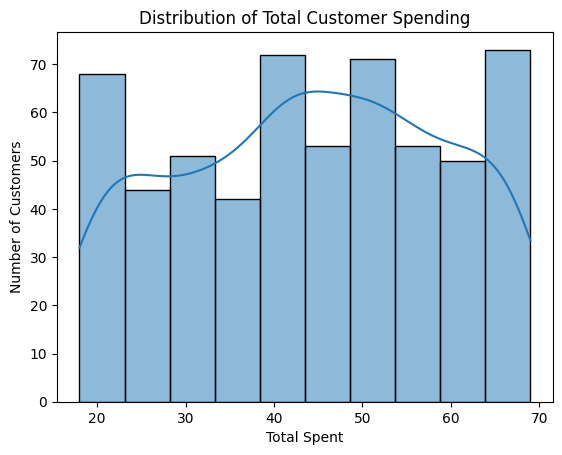

In [13]:
sns.histplot(data=df, x="age", bins=10, kde=True)
plt.title("Distribution of Total Customer Spending")
plt.xlabel("Total Spent")
plt.ylabel("Number of Customers")


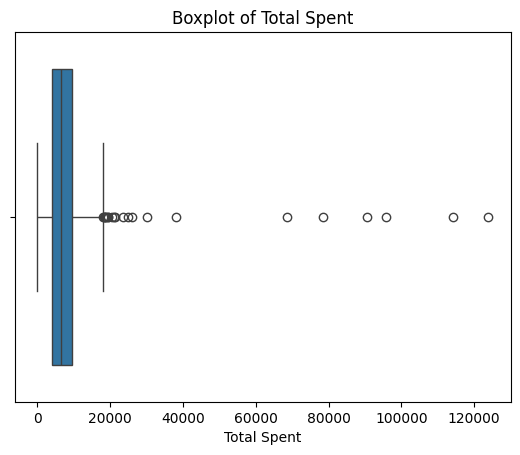

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["total_spent"])

plt.title("Boxplot of Total Spent")
plt.xlabel("Total Spent")
plt.show()

In [15]:
numeric_cols = [
    "age",
    "num_orders",
    "total_spent",
    "avg_order_value",
    "recency_days"
]

In [16]:
correlation = df[numeric_cols].corr()

print(correlation)

                      age  num_orders  total_spent  avg_order_value  \
age              1.000000    0.068896     0.069013         0.051659   
num_orders       0.068896    1.000000     0.426799         0.123780   
total_spent      0.069013    0.426799     1.000000         0.885788   
avg_order_value  0.051659    0.123780     0.885788         1.000000   
recency_days     0.020451    0.067445     0.011678         0.014436   

                 recency_days  
age                  0.020451  
num_orders           0.067445  
total_spent          0.011678  
avg_order_value      0.014436  
recency_days         1.000000  


Text(0.5, 1.0, 'Correlation Heatmap of E-commerce Dataset')

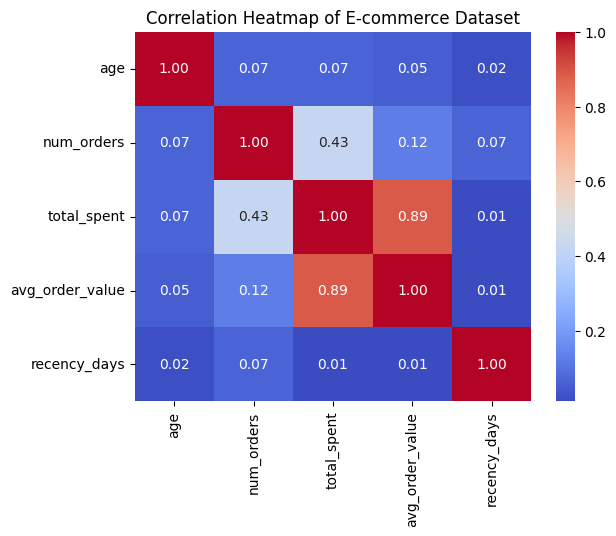

In [17]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of E-commerce Dataset")



In [18]:
#missing values: numerical values
num_cols = ['age','total_spent']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [19]:
#categorical column with mode
cat_cols = ['gender','country','device_type','preferred_category']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         605 non-null    int64  
 1   age                 605 non-null    float64
 2   gender              605 non-null    str    
 3   country             605 non-null    str    
 4   signup_date         605 non-null    str    
 5   last_purchase_date  605 non-null    str    
 6   num_orders          605 non-null    int64  
 7   total_spent         605 non-null    float64
 8   avg_order_value     605 non-null    float64
 9   recency_days        605 non-null    int64  
 10  is_premium_member   605 non-null    int64  
 11  device_type         605 non-null    str    
 12  preferred_category  605 non-null    str    
 13  churned             605 non-null    int64  
dtypes: float64(3), int64(5), str(6)
memory usage: 91.8 KB


In [21]:
df.describe()

,customer_id,age,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,churned
count,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000
mean,10301.439669,44.213223,5.945455,7973.496612,1279.377471,456.029752,0.294215,0.036364
std,173.636071,14.628484,2.332892,10057.492868,1123.841840,405.810389,0.456066,0.187348
min,10001.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,10151.000000,33.000000,4.000000,4080.500000,795.780000,128.000000,0.000000,0.000000
50%,10302.000000,45.000000,6.000000,6533.980000,1152.530000,327.000000,0.000000,0.000000
75%,10451.000000,56.000000,7.000000,9359.850000,1615.030000,696.000000,1.000000,0.000000
max,10600.000000,69.000000,13.000000,123891.810000,11431.900000,1685.000000,1.000000,1.000000


In [22]:
#date and time
print("date",df['signup_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'],errors='coerce')
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'],errors ='coerce')
print("date",df['signup_date'])

date 0      2022-01-27
1      2025-01-12
2      2021-04-25
3      2021-02-23
4      2021-06-07
          ...    
600    2023-09-04
601    2024-05-11
602    2020-12-01
603    2023-12-20
604    2024-06-16
Name: signup_date, Length: 605, dtype: str
date 0     2022-01-27
1     2025-01-12
2     2021-04-25
3     2021-02-23
4     2021-06-07
         ...    
600   2023-09-04
601   2024-05-11
602   2020-12-01
603   2023-12-20
604   2024-06-16
Name: signup_date, Length: 605, dtype: datetime64[us]


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         605 non-null    int64         
 1   age                 605 non-null    float64       
 2   gender              605 non-null    str           
 3   country             605 non-null    str           
 4   signup_date         605 non-null    datetime64[us]
 5   last_purchase_date  605 non-null    datetime64[us]
 6   num_orders          605 non-null    int64         
 7   total_spent         605 non-null    float64       
 8   avg_order_value     605 non-null    float64       
 9   recency_days        605 non-null    int64         
 10  is_premium_member   605 non-null    int64         
 11  device_type         605 non-null    str           
 12  preferred_category  605 non-null    str           
 13  churned             605 non-null    int64         
dtypes: da

In [24]:
#derived feature: days between signup and last purchase
df['customer_lifetime_days'] = (df['last_purchase_date'] - df['signup_date']).dt.days
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             605 non-null    int64         
 1   age                     605 non-null    float64       
 2   gender                  605 non-null    str           
 3   country                 605 non-null    str           
 4   signup_date             605 non-null    datetime64[us]
 5   last_purchase_date      605 non-null    datetime64[us]
 6   num_orders              605 non-null    int64         
 7   total_spent             605 non-null    float64       
 8   avg_order_value         605 non-null    float64       
 9   recency_days            605 non-null    int64         
 10  is_premium_member       605 non-null    int64         
 11  device_type             605 non-null    str           
 12  preferred_category      605 non-null    str           
 13  c

In [25]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             605 non-null    int64         
 1   age                     605 non-null    float64       
 2   gender                  605 non-null    str           
 3   country                 605 non-null    str           
 4   signup_date             605 non-null    datetime64[us]
 5   last_purchase_date      605 non-null    datetime64[us]
 6   num_orders              605 non-null    int64         
 7   total_spent             605 non-null    float64       
 8   avg_order_value         605 non-null    float64       
 9   recency_days            605 non-null    int64         
 10  is_premium_member       605 non-null    int64         
 11  device_type             605 non-null    str           
 12  preferred_category      605 non-null    str           
 13  c

In [26]:
#Drop irrelevant Columns
df.drop(columns = ['customer_id'],inplace = True)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   age                     605 non-null    float64       
 1   gender                  605 non-null    str           
 2   country                 605 non-null    str           
 3   signup_date             605 non-null    datetime64[us]
 4   last_purchase_date      605 non-null    datetime64[us]
 5   num_orders              605 non-null    int64         
 6   total_spent             605 non-null    float64       
 7   avg_order_value         605 non-null    float64       
 8   recency_days            605 non-null    int64         
 9   is_premium_member       605 non-null    int64         
 10  device_type             605 non-null    str           
 11  preferred_category      605 non-null    str           
 12  churned                 605 non-null    int64         
 13  c

In [31]:
#Encode Categorical Variable
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

label_enc = LabelEncoder()
for col in cat_cols:
    df[col] = label_enc.fit_transform(df[col])

In [32]:
#Scale Numerical Columns
scaler = StandardScaler()
num_features = ['age','num_orders','total_spent','avg_order_value','recency_days','customer_lifetime_days']
df[num_features] = scaler.fit_transform(df[num_features])

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   age                     605 non-null    float64       
 1   gender                  605 non-null    int64         
 2   country                 605 non-null    int64         
 3   signup_date             605 non-null    datetime64[us]
 4   last_purchase_date      605 non-null    datetime64[us]
 5   num_orders              605 non-null    float64       
 6   total_spent             605 non-null    float64       
 7   avg_order_value         605 non-null    float64       
 8   recency_days            605 non-null    float64       
 9   is_premium_member       605 non-null    int64         
 10  device_type             605 non-null    int64         
 11  preferred_category      605 non-null    int64         
 12  churned                 605 non-null    int64         
 13  c

In [34]:
#min max
scaler = MinMaxScaler()
num_features = ['age','num_orders','total_spent','avg_order_value','recency_days','customer_lifetime_days']
df[num_features] = scaler.fit_transform(df[num_features])

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   age                     605 non-null    float64       
 1   gender                  605 non-null    int64         
 2   country                 605 non-null    int64         
 3   signup_date             605 non-null    datetime64[us]
 4   last_purchase_date      605 non-null    datetime64[us]
 5   num_orders              605 non-null    float64       
 6   total_spent             605 non-null    float64       
 7   avg_order_value         605 non-null    float64       
 8   recency_days            605 non-null    float64       
 9   is_premium_member       605 non-null    int64         
 10  device_type             605 non-null    int64         
 11  preferred_category      605 non-null    int64         
 12  churned                 605 non-null    int64         
 13  c

In [36]:
df.head()

,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned,customer_lifetime_days
0,0.745098,1,3,2022-01-27,2024-04-27,0.769231,0.107136,0.116107,0.309382,0,1,4,0,0.478717
1,1.000000,2,4,2025-01-12,2025-08-01,0.769231,0.052739,0.027021,0.035629,0,1,3,0,0.117201
2,0.549020,0,5,2021-04-25,2021-06-01,0.384615,0.027539,0.059690,0.939430,0,1,3,0,0.021574
3,0.274510,1,3,2021-02-23,2023-09-22,0.384615,0.036338,0.078762,0.438836,0,1,3,0,0.548688
4,0.823529,0,3,2021-06-07,2021-12-11,0.538462,0.031012,0.048012,0.824822,0,2,0,0,0.109038


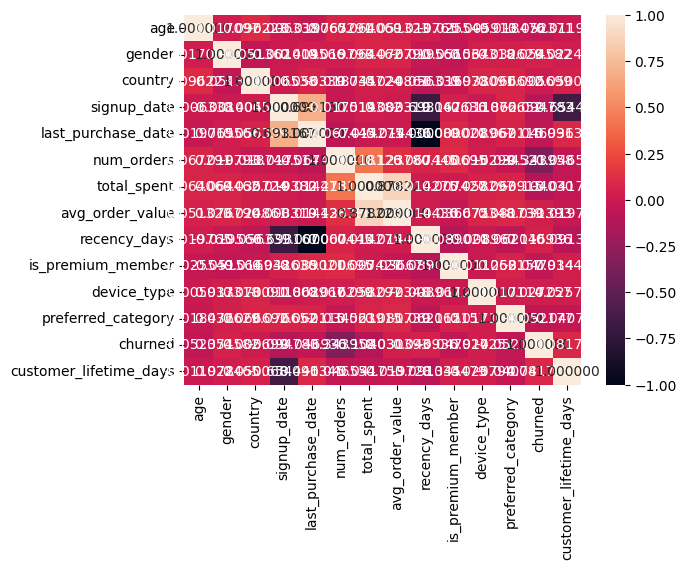

In [37]:
#cor and heatmap
corr = df.corr()
sns.heatmap(corr,annot=True,fmt='2f')
plt.show()
df.to_csv("ecommerce_customers_unit1 (1).csv",index=False)